# Longitudinal Tire Model Test & Debug
종방향 타이어 모델 테스트 및 디버깅 노트북 (수직력 비례 모델)

## 목적
- LongitudinalTireModel 동작 확인
- **입력**: ω_wheel (휠 각속도), V_wheel_x (차량 속도), F_z_tire (수직력) → **출력**: F_x_tire (종방향 타이어 힘)
- 수직력 비례 모델: `F_x_tire = C_x × F_z_tire × κ` (단, `|F_x_tire| ≤ μ × F_z_tire`)

In [2]:
# 필요한 라이브러리 import
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 프로젝트 루트를 Python path에 추가
project_root = Path.cwd().parent.parent.parent.parent.parent.parent
sys.path.insert(0, str(project_root))

# LongitudinalTireModel import
from vehicle_sim.models.e_corner.tire.longitudinal.longitudinal_tire import LongitudinalTireModel

print("Import 성공!")

Import 성공!


## 1. 기본 동작 테스트
LongitudinalTireModel 생성 및 기본 파라미터 확인

In [3]:
# 모델 생성
tire = LongitudinalTireModel()

print("=== Longitudinal Tire Model Parameters ===")
print(f"종방향 타이어 강성 계수 C_x: {tire.params.C_x} (무차원)")
print(f"마찰 계수 μ: {tire.params.mu}")
print(f"최소 속도 v_min: {tire.params.v_min} m/s")
print(f"타이어 유효 반지름 R_eff: {tire.params.R_eff} m")

print("\n수직력 비례 모델 특징:")
print("  F_x_tire = C_x × F_z_tire × κ")
print("  수직력이 클수록 더 큰 종방향 힘 발생")

=== Longitudinal Tire Model Parameters ===
종방향 타이어 강성 계수 C_x: 231500.0 (무차원)
마찰 계수 μ: 1.0
최소 속도 v_min: 0.1 m/s
타이어 유효 반지름 R_eff: 0.321 m

수직력 비례 모델 특징:
  F_x_tire = C_x × F_z_tire × κ
  수직력이 클수록 더 큰 종방향 힘 발생


## 2. 슬립 비율 계산 테스트
**입력**: ω_wheel, V_wheel_x  
**출력**: κ (slip ratio)

In [4]:
# 테스트 케이스
test_cases = [
    # (ω_wheel [rad/s], V_wheel_x [m/s], 설명)
    (33.33, 10.0, "완전 구름 (no slip)"),
    (40.0, 10.0, "구동 슬립 (가속)"),
    (25.0, 10.0, "제동 슬립 (감속)"),
    (10.0, 0.05, "저속 (슬립 계산 불가)"),
]

print("=== 슬립 비율 계산 테스트 ===")
print(f"타이어 반지름 R_eff = {tire.params.R_eff} m\n")

for omega, V_x, desc in test_cases:
    kappa = tire.calculate_slip_ratio(omega, V_x)
    V_wheel = omega * tire.params.R_eff
    print(f"{desc}:")
    print(f"  ω_wheel = {omega:.2f} rad/s, V_wheel_x = {V_x:.2f} m/s")
    print(f"  V_wheel = ω × R = {V_wheel:.2f} m/s")
    print(f"  κ = {kappa:.4f}\n")

=== 슬립 비율 계산 테스트 ===
타이어 반지름 R_eff = 0.321 m

완전 구름 (no slip):
  ω_wheel = 33.33 rad/s, V_wheel_x = 10.00 m/s
  V_wheel = ω × R = 10.70 m/s
  κ = 0.0699

구동 슬립 (가속):
  ω_wheel = 40.00 rad/s, V_wheel_x = 10.00 m/s
  V_wheel = ω × R = 12.84 m/s
  κ = 0.2840

제동 슬립 (감속):
  ω_wheel = 25.00 rad/s, V_wheel_x = 10.00 m/s
  V_wheel = ω × R = 8.03 m/s
  κ = -0.1975

저속 (슬립 계산 불가):
  ω_wheel = 10.00 rad/s, V_wheel_x = 0.05 m/s
  V_wheel = ω × R = 3.21 m/s
  κ = 31.6000



## 3. 타이어 힘 계산 테스트 - 슬립 비율 변화
**입력**: κ (변화), F_z_tire (일정)  
**출력**: F_x_tire

In [5]:
# 슬립 비율 범위
kappa_range = np.linspace(-0.3, 0.3, 200)

# 수직력 (일정)
F_z_tire = 5000.0  # [N]

# 타이어 힘 계산
F_x_tire_array = np.array([tire.calculate_force(k, F_z_tire) for k in kappa_range])

# 이론적 마찰 한계
F_x_max = tire.params.mu * F_z_tire

print(f"수직력 F_z_tire = {F_z_tire} N")
print(f"마찰 한계 F_x_max = μ × F_z = {F_x_max} N")
print(f"최대 타이어 힘 (계산) = {F_x_tire_array.max():.1f} N")

수직력 F_z_tire = 5000.0 N
마찰 한계 F_x_max = μ × F_z = 5000.0 N
최대 타이어 힘 (계산) = 5000.0 N


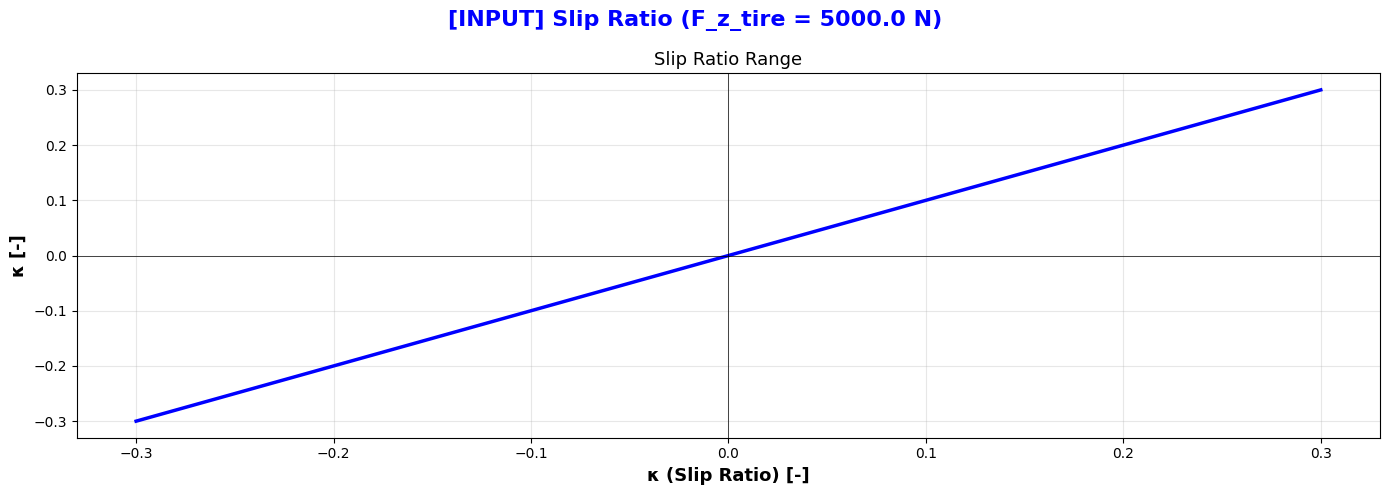

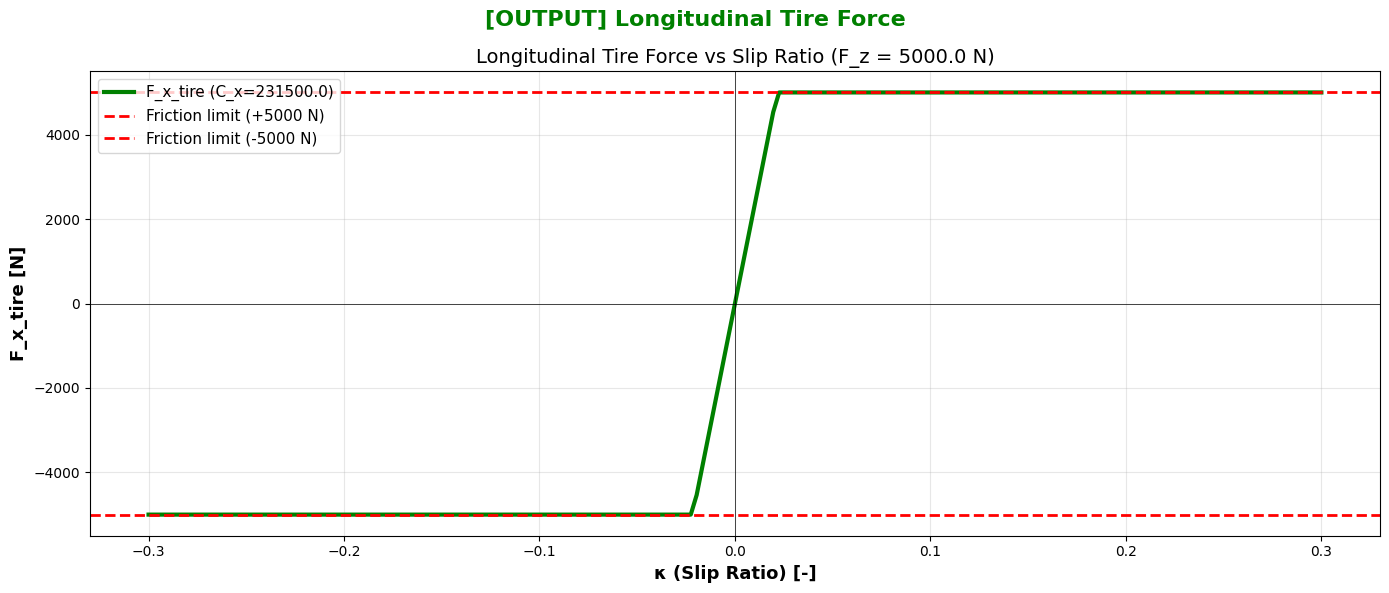

In [6]:
# ========================================
# [입력 INPUT] 시각화
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle(f'[INPUT] Slip Ratio (F_z_tire = {F_z_tire} N)', fontsize=16, fontweight='bold', color='blue')

ax.plot(kappa_range, kappa_range, 'b-', linewidth=2.5)
ax.set_xlabel('κ (Slip Ratio) [-]', fontsize=13, fontweight='bold')
ax.set_ylabel('κ [-]', fontsize=13, fontweight='bold')
ax.set_title('Slip Ratio Range', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
fig.suptitle('[OUTPUT] Longitudinal Tire Force', fontsize=16, fontweight='bold', color='green')

ax.plot(kappa_range, F_x_tire_array, 'g-', linewidth=3, label=f'F_x_tire (C_x={tire.params.C_x})')
ax.axhline(y=F_x_max, color='red', linestyle='--', linewidth=2, label=f'Friction limit (+{F_x_max:.0f} N)')
ax.axhline(y=-F_x_max, color='red', linestyle='--', linewidth=2, label=f'Friction limit (-{F_x_max:.0f} N)')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

ax.set_xlabel('κ (Slip Ratio) [-]', fontsize=13, fontweight='bold')
ax.set_ylabel('F_x_tire [N]', fontsize=13, fontweight='bold')
ax.set_title(f'Longitudinal Tire Force vs Slip Ratio (F_z = {F_z_tire} N)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

## 4. 수직력 변화 영향 테스트
**입력**: κ (일정), F_z_tire (변화)  
**출력**: F_x_tire

수직력 비례 모델의 핵심: 수직력에 비례하는 타이어 힘

In [7]:
# 슬립 비율 범위
kappa_range = np.linspace(-0.2, 0.2, 200)

# 다양한 수직력
F_z_values = [3000.0, 5000.0, 7000.0, 9000.0]  # [N]

results_Fz = {}

for F_z in F_z_values:
    F_x_array = np.array([tire.calculate_force(k, F_z) for k in kappa_range])
    results_Fz[F_z] = F_x_array

print(f"수직력 변화 테스트 완료! 테스트한 F_z 값: {F_z_values}")

수직력 변화 테스트 완료! 테스트한 F_z 값: [3000.0, 5000.0, 7000.0, 9000.0]


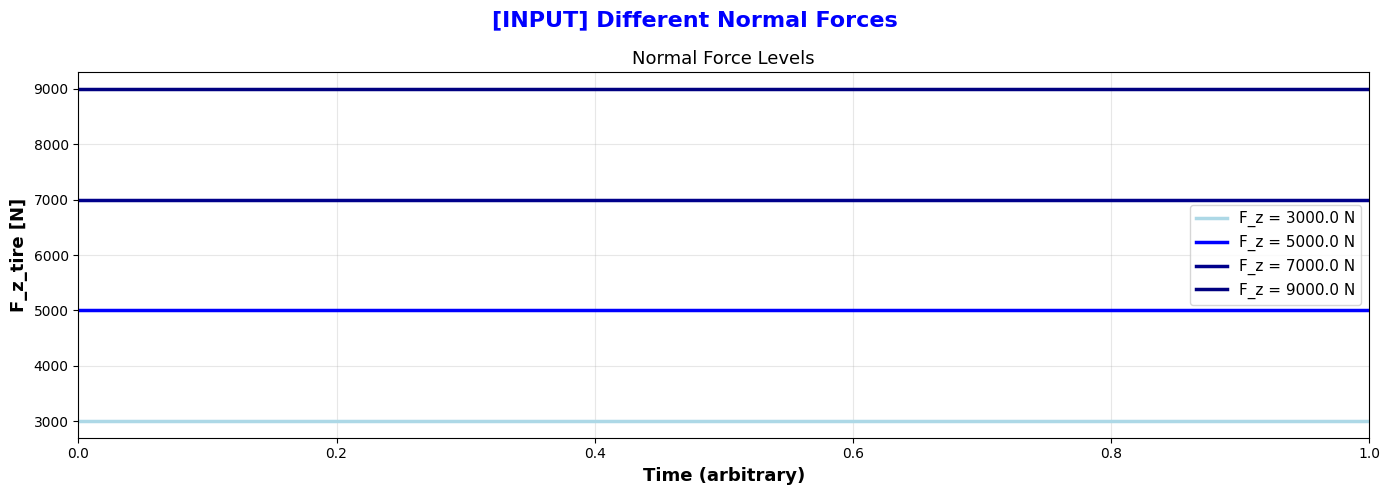

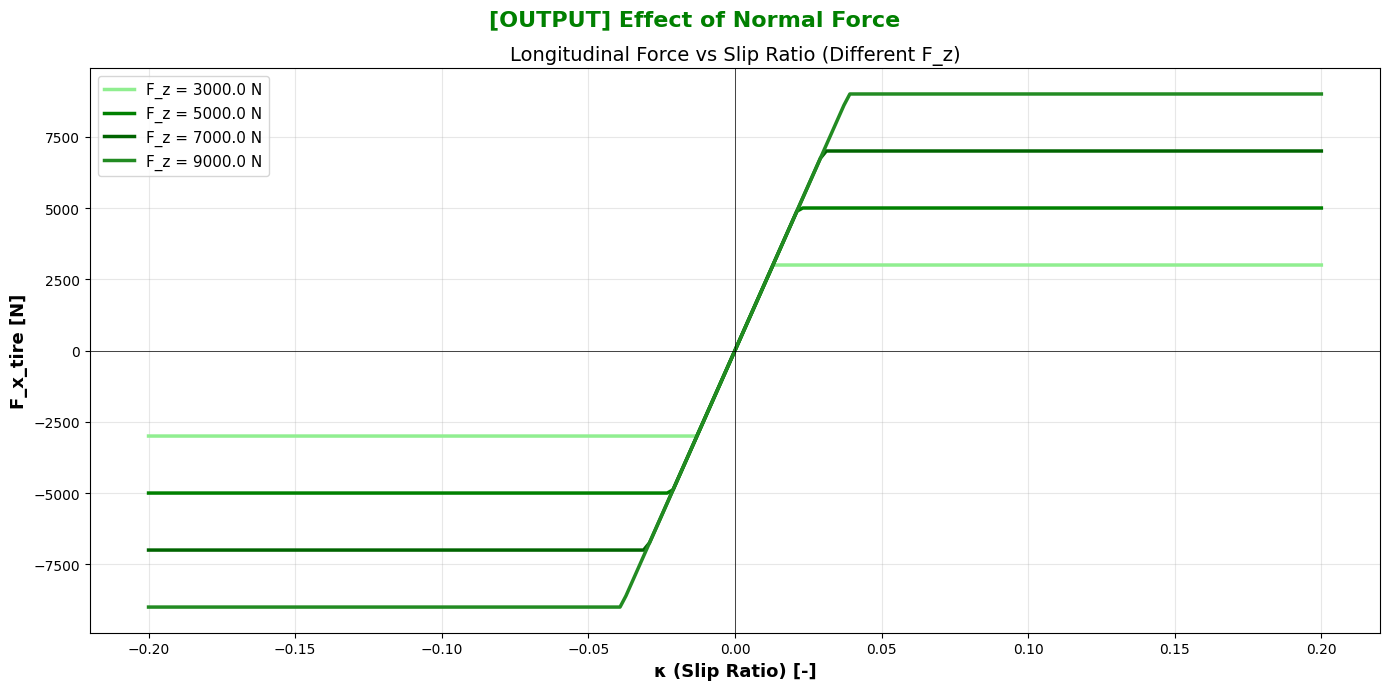


✓ 관찰: F_z가 클수록 타이어 힘도 비례하여 증가 (수직력 비례 모델 특성)


In [8]:
# ========================================
# [입력 INPUT] 시각화
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle('[INPUT] Different Normal Forces', fontsize=16, fontweight='bold', color='blue')

colors = ['lightblue', 'blue', 'darkblue', 'navy']
for F_z, color in zip(F_z_values, colors):
    ax.axhline(y=F_z, color=color, linestyle='-', linewidth=2.5, label=f'F_z = {F_z} N')

ax.set_xlabel('Time (arbitrary)', fontsize=13, fontweight='bold')
ax.set_ylabel('F_z_tire [N]', fontsize=13, fontweight='bold')
ax.set_title('Normal Force Levels', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='right')
ax.set_xlim([0, 1])

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화 - 수직력 영향
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
fig.suptitle('[OUTPUT] Effect of Normal Force', fontsize=16, fontweight='bold', color='green')

colors = ['lightgreen', 'green', 'darkgreen', 'forestgreen']
for (F_z, F_x_array), color in zip(results_Fz.items(), colors):
    ax.plot(kappa_range, F_x_array, linewidth=2.5, label=f'F_z = {F_z} N', color=color)

ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

ax.set_xlabel('κ (Slip Ratio) [-]', fontsize=13, fontweight='bold')
ax.set_ylabel('F_x_tire [N]', fontsize=13, fontweight='bold')
ax.set_title('Longitudinal Force vs Slip Ratio (Different F_z)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

print("\n✓ 관찰: F_z가 클수록 타이어 힘도 비례하여 증가 (수직력 비례 모델 특성)")

## 5. 마찰 한계 테스트
**입력**: κ (큰 값), F_z_tire  
**출력**: F_x_tire (포화 확인)

In [9]:
# 큰 슬립 비율 범위 (마찰 한계 테스트)
kappa_large = np.linspace(-1.0, 1.0, 300)

# 수직력
F_z_tire = 6000.0  # [N]

# 타이어 힘 계산
F_x_large = np.array([tire.calculate_force(k, F_z_tire) for k in kappa_large])

# 선형 모델 (포화 없이)
F_x_linear = tire.params.C_x * F_z_tire * kappa_large

# 마찰 한계
F_x_max = tire.params.mu * F_z_tire

print(f"수직력 F_z_tire = {F_z_tire} N")
print(f"마찰 한계 = ±{F_x_max} N")
print(f"포화 발생 슬립 비율 ≈ {F_x_max / (tire.params.C_x * F_z_tire):.3f}")

수직력 F_z_tire = 6000.0 N
마찰 한계 = ±6000.0 N
포화 발생 슬립 비율 ≈ 0.000


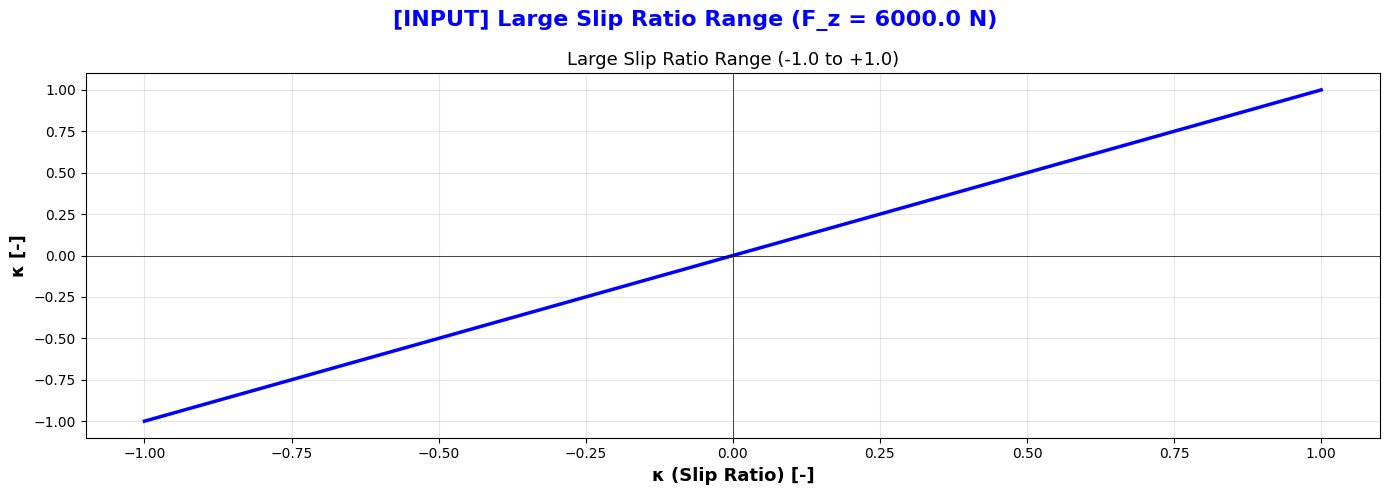

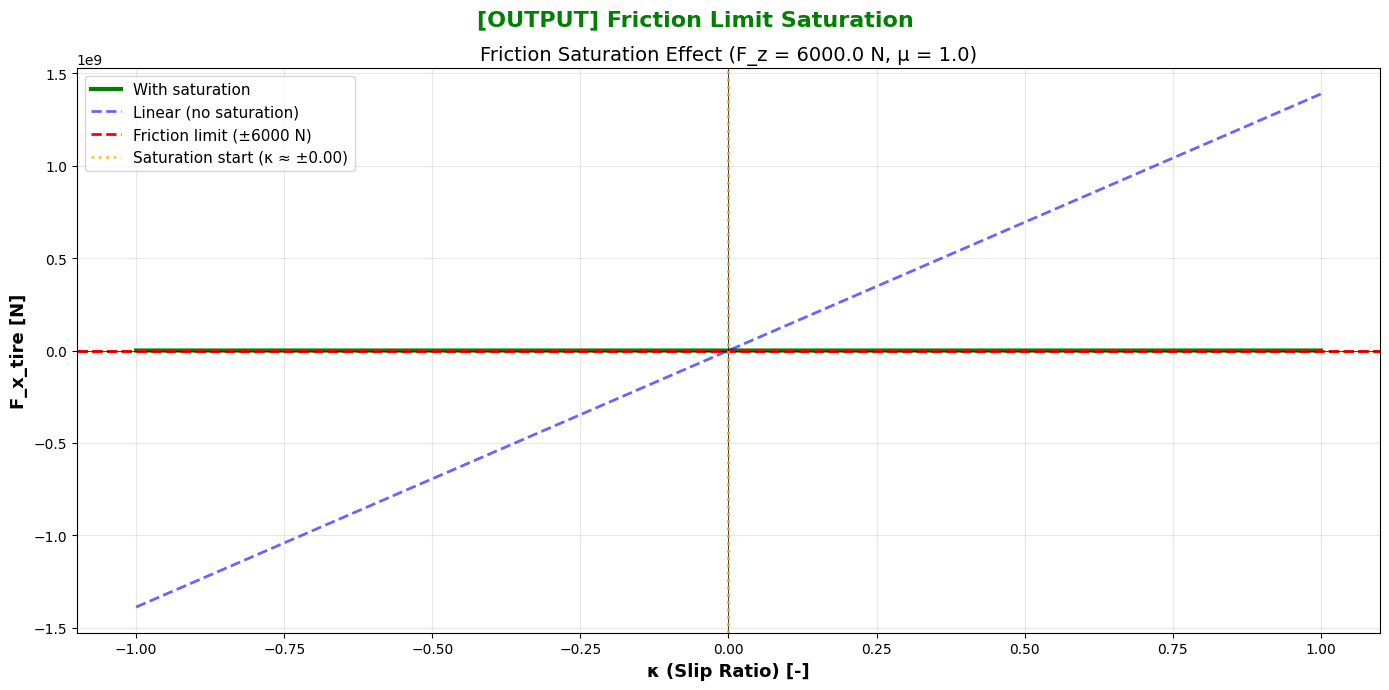


✓ 관찰: 슬립이 커지면 선형 영역에서 벗어나 마찰 한계에 포화됨


In [10]:
# ========================================
# [입력 INPUT] 시각화
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle(f'[INPUT] Large Slip Ratio Range (F_z = {F_z_tire} N)', fontsize=16, fontweight='bold', color='blue')

ax.plot(kappa_large, kappa_large, 'b-', linewidth=2.5)
ax.set_xlabel('κ (Slip Ratio) [-]', fontsize=13, fontweight='bold')
ax.set_ylabel('κ [-]', fontsize=13, fontweight='bold')
ax.set_title('Large Slip Ratio Range (-1.0 to +1.0)', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화 - 마찰 한계
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
fig.suptitle('[OUTPUT] Friction Limit Saturation', fontsize=16, fontweight='bold', color='green')

ax.plot(kappa_large, F_x_large, 'g-', linewidth=3, label='With saturation')
ax.plot(kappa_large, F_x_linear, 'b--', linewidth=2, alpha=0.6, label='Linear (no saturation)')
ax.axhline(y=F_x_max, color='red', linestyle='--', linewidth=2, label=f'Friction limit (±{F_x_max:.0f} N)')
ax.axhline(y=-F_x_max, color='red', linestyle='--', linewidth=2)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# 포화 시작점 표시
kappa_sat = F_x_max / (tire.params.C_x * F_z_tire)
ax.axvline(x=kappa_sat, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'Saturation start (κ ≈ ±{kappa_sat:.2f})')
ax.axvline(x=-kappa_sat, color='orange', linestyle=':', linewidth=2, alpha=0.7)

ax.set_xlabel('κ (Slip Ratio) [-]', fontsize=13, fontweight='bold')
ax.set_ylabel('F_x_tire [N]', fontsize=13, fontweight='bold')
ax.set_title(f'Friction Saturation Effect (F_z = {F_z_tire} N, μ = {tire.params.mu})', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

print("\n✓ 관찰: 슬립이 커지면 선형 영역에서 벗어나 마찰 한계에 포화됨")

## 6. 파라미터 변화 테스트 (C_x)
**입력**: κ, F_z_tire (일정), C_x (변화)  
**출력**: F_x_tire

In [11]:
# 슬립 비율 범위
kappa_range = np.linspace(-0.15, 0.15, 200)

# 수직력 (일정)
F_z_tire = 5000.0  # [N]

# 다양한 C_x 값
C_x_values = [5.0, 10.0, 15.0, 20.0]

results_Cx = {}

for C_x in C_x_values:
    tire_test = LongitudinalTireModel()
    tire_test.params.C_x = C_x
    
    F_x_array = np.array([tire_test.calculate_force(k, F_z_tire) for k in kappa_range])
    results_Cx[C_x] = F_x_array

print(f"C_x 변화 테스트 완료! 테스트한 C_x 값: {C_x_values}")

C_x 변화 테스트 완료! 테스트한 C_x 값: [5.0, 10.0, 15.0, 20.0]


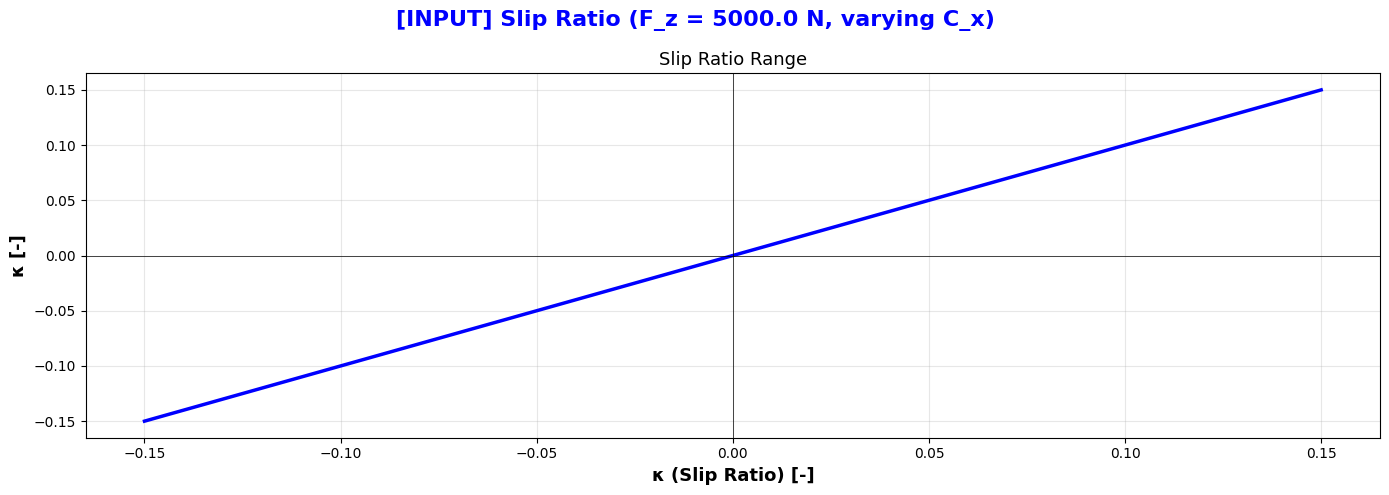

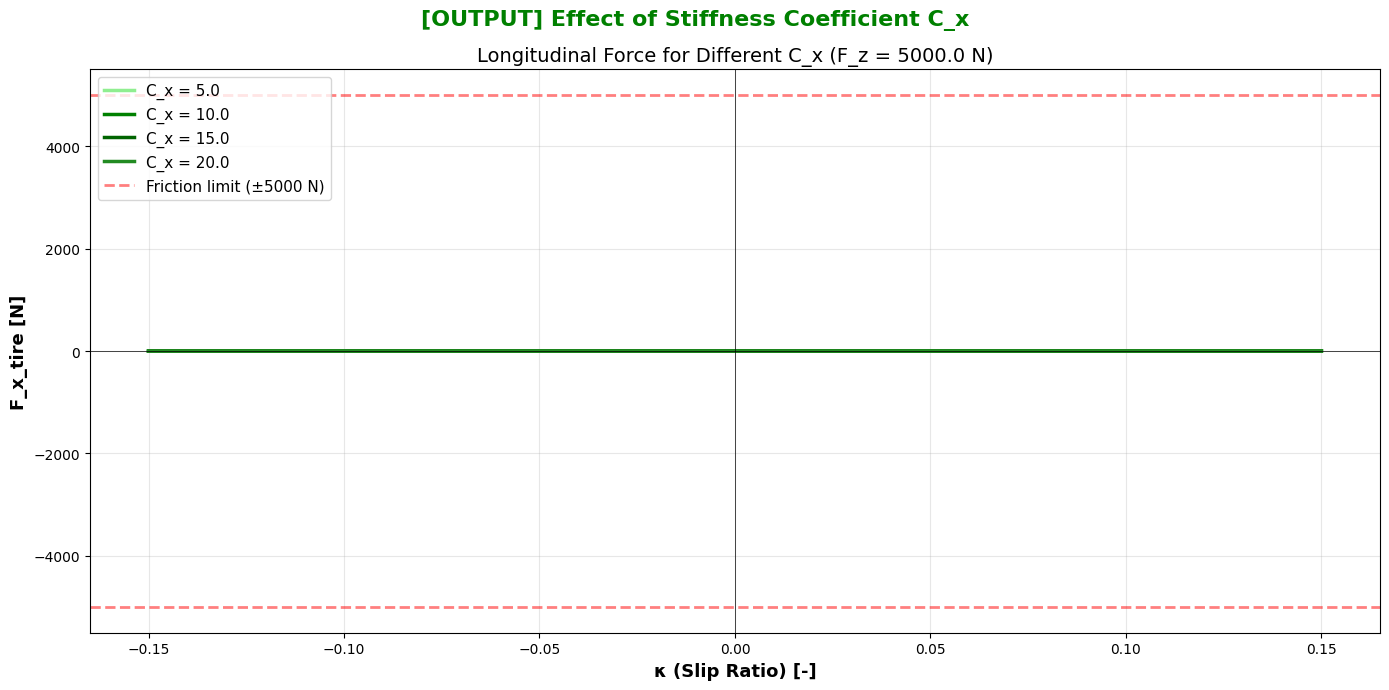


✓ 관찰: C_x가 클수록 같은 슬립에서 더 큰 타이어 힘 발생 (강성 증가)


In [12]:
# ========================================
# [입력 INPUT] 시각화
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle(f'[INPUT] Slip Ratio (F_z = {F_z_tire} N, varying C_x)', fontsize=16, fontweight='bold', color='blue')

ax.plot(kappa_range, kappa_range, 'b-', linewidth=2.5)
ax.set_xlabel('κ (Slip Ratio) [-]', fontsize=13, fontweight='bold')
ax.set_ylabel('κ [-]', fontsize=13, fontweight='bold')
ax.set_title('Slip Ratio Range', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화 - C_x 영향
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
fig.suptitle('[OUTPUT] Effect of Stiffness Coefficient C_x', fontsize=16, fontweight='bold', color='green')

colors = ['lightgreen', 'green', 'darkgreen', 'forestgreen']
for (C_x, F_x_array), color in zip(results_Cx.items(), colors):
    ax.plot(kappa_range, F_x_array, linewidth=2.5, label=f'C_x = {C_x}', color=color)

# 마찰 한계 (μ × F_z)
F_x_max = tire.params.mu * F_z_tire
ax.axhline(y=F_x_max, color='red', linestyle='--', linewidth=2, alpha=0.5, label=f'Friction limit (±{F_x_max:.0f} N)')
ax.axhline(y=-F_x_max, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

ax.set_xlabel('κ (Slip Ratio) [-]', fontsize=13, fontweight='bold')
ax.set_ylabel('F_x_tire [N]', fontsize=13, fontweight='bold')
ax.set_title(f'Longitudinal Force for Different C_x (F_z = {F_z_tire} N)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

print("\n✓ 관찰: C_x가 클수록 같은 슬립에서 더 큰 타이어 힘 발생 (강성 증가)")

## 7. 요약

### 수직력 비례 모델 특징:
```
F_x_tire = C_x × F_z_tire × κ
단, |F_x_tire| ≤ μ × F_z_tire
```

### 검증 완료:
- ✓ 슬립 비율 계산 (완전 구름, 구동/제동 슬립)
- ✓ 수직력 비례 모델 (수직력 비례)
- ✓ 수직력 변화 영향
- ✓ 마찰 한계 포화
- ✓ 강성 계수 C_x 영향

### 핵심 특성:
1. **수직력 비례**: F_z가 클수록 F_x도 증가
2. **선형 + 포화**: 작은 슬립에서는 선형, 큰 슬립에서는 마찰 한계에 포화
3. **C_x 정규화**: 무차원 계수로 타이어 특성 조정

In [13]:
print("=" * 60)
print("Longitudinal Tire Model Test Summary")
print("=" * 60)
print("\n✓ 모델: 수직력 비례 모델 (F_x = C_x × F_z × κ)")
print("✓ 슬립 비율 계산: 통과")
print("✓ 수직력 비례 특성: 통과")
print("✓ 마찰 한계 포화: 통과")
print("✓ 파라미터 변화 (C_x): 통과")
print("\n모든 테스트 완료!")
print("=" * 60)

Longitudinal Tire Model Test Summary

✓ 모델: 수직력 비례 모델 (F_x = C_x × F_z × κ)
✓ 슬립 비율 계산: 통과
✓ 수직력 비례 특성: 통과
✓ 마찰 한계 포화: 통과
✓ 파라미터 변화 (C_x): 통과

모든 테스트 완료!
